# Learned Word Embeddings and Neural Text Classification

This notebook continues the text-processing progression:

```text
Raw text
→ training/test split
→ tokenization
→ vocabulary
→ integer sequences
→ padding
→ embedding layer
→ neural text classification
```

The first workflow uses three books and Keras tokenization. The second workflow extends the experiments to four books and compares additional Dense, convolutional, recurrent, and pretrained-embedding models.


## Part 1: Three-Book Text Classification with Learned Embeddings


We will download 3 books:


*   The Call of the Wild, by Jack London
*   Dracula, by Bram Stoker
*   The Adventures of Sherlock Holmes, by Arthur Conan Doyle

We will split the books into a collection of paragraphs and train a machine learning model to determine the book a paragraph was taken from.

In [ ]:
import bs4 as bs
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from tensorflow.keras.initializers import *

from keras.models import Model
from keras.regularizers import l2

from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, Callback

In [ ]:
def get_paragraph_list(url,skip):
    paragraphs = []
    data = urllib.request.urlopen(url).read()
    soup = bs.BeautifulSoup(data,'lxml')
    for paragraph in soup.find_all('p'):
        par  = paragraph.get_text()
        if par:
            if len(par)>=25:
              paragraphs.append(par)
    return paragraphs[skip:]

url_list = ['http://www.gutenberg.org/files/215/215-h/215-h.htm', 'http://www.gutenberg.org/files/345/345-h/345-h.htm', 'http://www.gutenberg.org/files/1661/1661-h/1661-h.htm']

paragraphs = []
targets = []
first_par = []
skip = [1,4,0]
for u, url in enumerate(url_list):
    par = get_paragraph_list(url,skip[u])
    paragraphs = paragraphs + par
    targets = targets + [u for i in par]
    print('\nBook {} contains {} paragraphs'.format(u,len(par)))
    lengths = np.array([len(wl) for wl in par])
    print('Paragraph length stats:')
    print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
    print('First paragraph:')
    print(par[0])



Book 0 contains 328 paragraphs
Paragraph length stats:
min = 28 max = 1558 mean = 532.960366
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1788 paragraphs
Paragraph length stats:
min = 25 max = 4713 mean = 462.699664
First paragraph:
3 May. Bistritz.—Left Munich at 8:35 P. M., on 1st May, arriving at
Vienna early next morning; should have arrived at 6:46, but train was an
hour late. Buda-Pesth seems a wonderful place, from the glimpse which I
got of

In [ ]:
np.random.seed(5361)
n = len(paragraphs)
ind = np.random.permutation(n)
x_test = [paragraphs[i] for i in ind[:n//5]]
x_train = [paragraphs[i] for i in ind[n//5:]]
y_test = tf.keras.utils.to_categorical([targets[i] for i in ind[:n//5]],3)
y_train = tf.keras.utils.to_categorical([targets[i] for i in ind[n//5:]],3)

In [ ]:
print(len(x_train))
print(y_train.shape)
print(len(x_test))
print(y_test.shape)

3484
(3484, 3)
871
(871, 3)


Now let's extract integer sequences to describe the data.

Notice that the vocabulary must be extracted from `x_train` only, since we are not allowed to use `x_test` for anything before testing.

Since all sequences must have the same length, we choose a length and pad with zeros the shorter sequences and truncate the longer ones.

We also choose `max_words`, the maximum vocabulary size. Only the most common words up to this limit are retained by the tokenizer. Position 0 is reserved for padding. If an explicit out-of-vocabulary token is required, the tokenizer can be created with an `oov_token`.


In [ ]:
max_words = 15000
seq_len = 250
tokenizer = Tokenizer(num_words = max_words,filters='’‘”“!"#$%&()*+,./:;<=>?@[\\]^_`{|}~\t\n\r')

tokenizer.fit_on_texts(x_train)

x_train_seq0 = tokenizer.texts_to_sequences(x_train)
x_test_seq0 = tokenizer.texts_to_sequences(x_test)

x_train_seq = pad_sequences(x_train_seq0,seq_len,truncating='post')
x_test_seq = pad_sequences(x_test_seq0,seq_len,truncating='post')

In [ ]:
x_train

['\n“Yes. He was brought up and remanded for further inquiries.”\n',
 '\n“Is it possible?” gasped the banker.\n',
 'Having been in the house, I could well believe him; but if he knew what\nI know, he would, I think, have raised his terms.',
 '\n“Ha!” said Holmes, looking keenly at her. “It is clear that\nMrs. Toller knows more about this matter than anyone else.”\n',
 '“You see, I do not know how to pick out any particular part of the\ndiary.” Even while he was speaking an idea dawned upon him, and he said\nwith unconscious simplicity, in a different voice, and with the naïveté\nof a child: “That’s quite true, upon my honour. Honest Indian!” I could\nnot but smile, at which he grimaced. “I gave myself away that time!” he\nsaid. “But do you know that, although I have kept the diary for months\npast, it never once struck me how I was going to find any particular\npart of it in case I wanted to look it up?” By this time my mind was\nmade up that the diary of a doctor who attended Lucy mig

In [ ]:
print(x_train_seq.shape)
print(x_test_seq.shape)

(3484, 250)
(871, 250)


Remove sequences that have no in-vocabulary words.

In [ ]:
print(np.sum(np.sum(x_train_seq,axis=1)==0))
print(np.sum(np.sum(x_test_seq,axis=1)==0))

has_valid_words = np.where(np.max(x_train_seq,axis=1)>0)[0]

x_train_seq = x_train_seq[has_valid_words]
x_train = [x_train[i] for i in has_valid_words]
y_train = y_train[has_valid_words]

has_valid_words = np.where(np.max(x_test_seq,axis=1)>0)[0]
x_test_seq = x_test_seq[has_valid_words]
x_test = [x_test[i] for i in has_valid_words]
y_test = y_test[has_valid_words]

print(np.sum(np.sum(x_train_seq,axis=1)==0))
print(np.sum(np.sum(x_test_seq,axis=1)==0))

3
0
0
0


In [ ]:
word_index = tokenizer.word_index
print('Found {} unique words'.format(len(word_index)))

Found 13993 unique words


We may also need to perform reverse queries such as 'which word has index i?'. For this, we build a list such that if i == word_index[w], word w is stored in position i in the list.

In [ ]:
word_list = ['UNKNOWN' for w in range(len(word_index)+1)]
for w in word_index.keys():
    word_list[word_index[w]] = w

Position 0 is reserved for unknown words. After that words are sorted by the frequency in which they appear in the text.

In [ ]:
for w in word_list[:20]:
  print(w)

UNKNOWN
the
and
i
to
of
a
he
in
that
it
was
his
you
as
is
for
with
my
not


Near the end we have the least-common words.

In [ ]:
for w in word_list[-20:]:
  print(w)

wild-eyed
fearing
choppy
tool-chest
raving
invoiced
importunate
inflicts
instructed
look-out
half-clad
carts
vegetables
splintering
wrestling
demurely
tackle
covering
caraffe
intends


Let's see a random training example and its corresponding sequence representation.

In [ ]:
r = np.random.randint(len(x_train))
print('r=',r)
print(x_train[r])
print(x_train_seq[r])

for i in x_train_seq[r]:
  if i>0:
    print(word_list[i],end=' ')

r= 2925
I think it will be best for her to go to bed tired out physically, so I
shall take her for a long walk by the cliffs to Robin Hood’s Bay and
back. She ought not to have much inclination for sleep-walking then.
[    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0    

In [ ]:
def plot_results(history):
  loss = history.history['loss']
  val_loss = history.history['val_loss']
  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')
  plt.show()

### Learned Embedding Layer

We will create an embedding layer. An embedding layer receives integer word indices and learns a dense vector for each word during text-classification training.

The important quantities are:

- `max_words`: the maximum number of words retained in the vocabulary,
- `emb_len`: the number of dimensions used to represent each word embedding,
- `seq_len`: the number of words in each paragraph after padding or truncation.

The weights of the embedding layer form a two-dimensional matrix. Each row contains the embedding vector associated with one vocabulary index, and each column corresponds to one embedding dimension.

The embedding matrix therefore has approximately:

```text
number of vocabulary indices × embedding dimension
```

The vectors are not manually specified when the embedding is learned from scratch. They are adjusted through backpropagation together with the classifier.


In [ ]:
def cnn1D(vocab_size,emb_len=50, seq_len=250, n_classes=3,dropout=0.5,n=128):
  ks = 7
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len,input_length=seq_len,name='embeddings'))
  model.add(Conv1D(n, kernel_size = ks, padding='same',activation="relu"))
  model.add(MaxPooling1D(4, padding='same'))
  model.add(Dropout(dropout))
  model.add(Conv1D(2*n, kernel_size = ks, padding='same', activation="relu"))
  model.add(MaxPooling1D(4, padding='same'))
  model.add(Dropout(dropout))
  model.add(Conv1D(2*n, kernel_size = ks, padding='same', activation="relu"))
  model.add(MaxPooling1D(4, padding='same'))
  model.add(Dropout(dropout))
  model.add(Flatten())
  #model.add(Dense(n,activation= 'relu'))
  #model.add(Dropout(dropout))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embeddings (Embedding)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_24 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 90ms/step - accuracy: 0.5789 - loss: 0.8561 - val_accuracy: 0.7049 - val_loss: 0.7863 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8121 - loss: 0.4996 - val_accuracy: 0.8301 - val_loss: 0.4650 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.9141 - loss: 0.2497 - val_accuracy: 0.8852 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.9606 - loss: 0.1164 - val_accuracy: 0.8978 - val_loss: 0.3109 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9853 - loss: 0.0482 - val_accuracy: 0.9070 - val_loss: 0.3307 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9906 - loss: 0.0291
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - accuracy: 0.9911 - loss: 

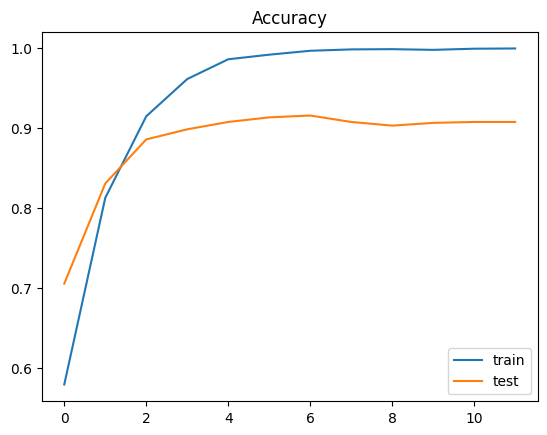

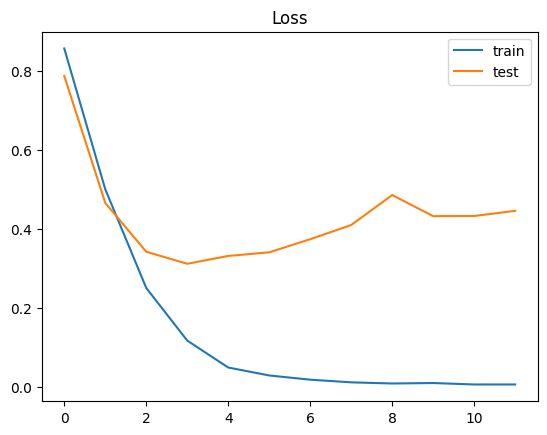

In [ ]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=2, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=5)

model = cnn1D(vocab_size = max_words, emb_len=50, seq_len=x_train_seq.shape[1], n=64)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(
    x_train_seq, y_train,
    validation_data=(x_test_seq, y_test),
    epochs = 30,
    verbose = 1,
    batch_size=32,
    callbacks = [rop, es]
)
acc = history.history['val_accuracy']
print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)

### Simpler One-Dimensional Convolutional Network

We will also try a simpler network that uses a single convolutional layer and global average pooling before the classification layer.


In [ ]:
def cnn1D_small(vocab_size,emb_len=100, seq_len=128, n_classes=3,dropout=0.5,n=128,kernel_size = 4):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len,input_length=seq_len,name='embeddings'))
  model.add(Conv1D(n, kernel_size = kernel_size, padding='same', activation="relu"))
  model.add(Dropout(dropout))
  model.add(GlobalAveragePooling1D())
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embeddings (Embedding)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_9      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.5737 - loss: 0.8603 - val_accuracy: 0.6073 - val_loss: 0.8203 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7004 - loss: 0.6870 - val_accuracy: 0.7796 - val_loss: 0.5822 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.8618 - loss: 0.4090 - val_accuracy: 0.8691 - val_loss: 0.3675 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9242 - loss: 0.2457 - val_accuracy: 0.9013 - val_loss: 0.2891 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9448 - loss: 0.1685 - val_accuracy: 0.9150 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9641 - loss: 0.1241 - val_accuracy: 0.9162 - val_loss: 0.2323 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.9718 - loss: 0

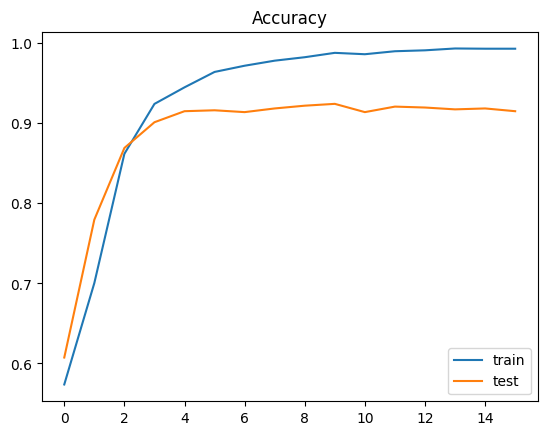

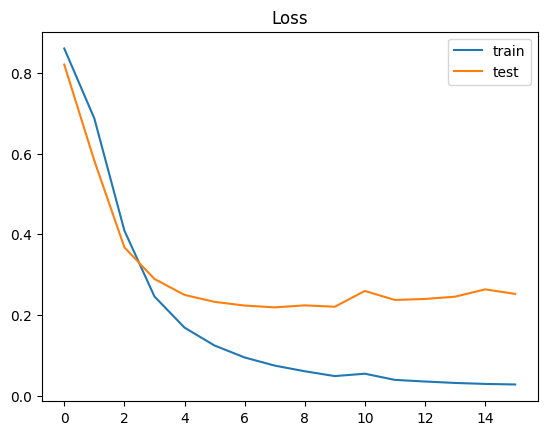

In [ ]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=6)

model = cnn1D_small(vocab_size = max_words, emb_len=50, seq_len=x_train_seq.shape[1], n=128)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(
    x_train_seq, y_train,
    validation_data=(x_test_seq, y_test),
    epochs = 30,
    verbose = 1,
    batch_size=32,
    callbacks = [rop, es]
)
acc = history.history['val_accuracy']
print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)

### Kernel-Size Comparison

We can also experiment with various kernel sizes to see how the width of the local text pattern affects classification performance.


Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.5633 - loss: 0.8687 - val_accuracy: 0.5959 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6458 - loss: 0.7526 - val_accuracy: 0.7348 - val_loss: 0.7017 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.8104 - loss: 0.5120 - val_accuracy: 0.8553 - val_loss: 0.4419 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8951 - loss: 0.3110 - val_accuracy: 0.8852 - val_loss: 0.3289 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9227 - loss: 0.2313 - val_accuracy: 0.9001 - val_loss: 0.2859 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9417 - loss: 0.1728 - val_accuracy: 0.9093 - val_loss: 0.2555 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9575 - loss: 0.

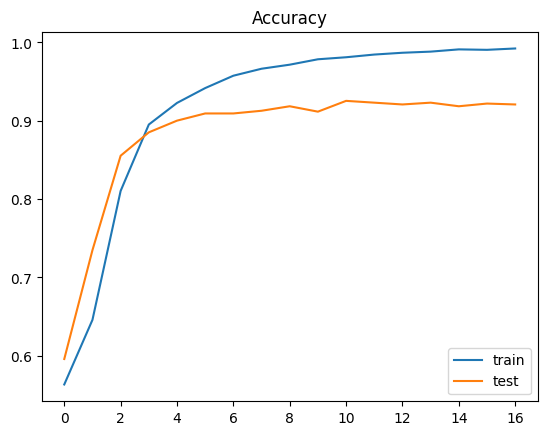

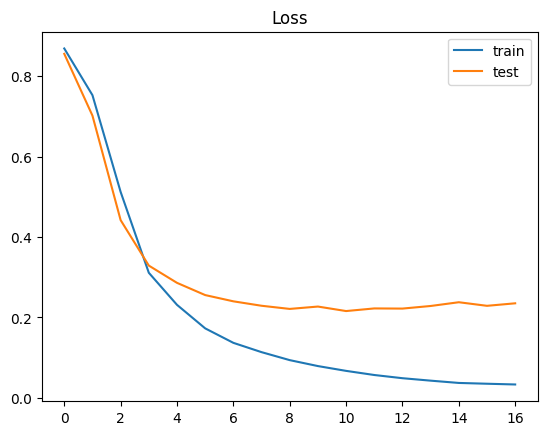

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - accuracy: 0.5863 - loss: 0.8506 - val_accuracy: 0.6108 - val_loss: 0.8140 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7064 - loss: 0.6728 - val_accuracy: 0.8014 - val_loss: 0.5951 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.8621 - loss: 0.4079 - val_accuracy: 0.8553 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9178 - loss: 0.2490 - val_accuracy: 0.9059 - val_loss: 0.2966 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.9446 - loss: 0.1718 - val_accuracy: 0.9082 - val_loss: 0.2562 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.9595 - loss: 0.1278 - val_accuracy: 0.9082 - val_loss: 0.2383 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - accuracy: 0.9667 - loss: 0

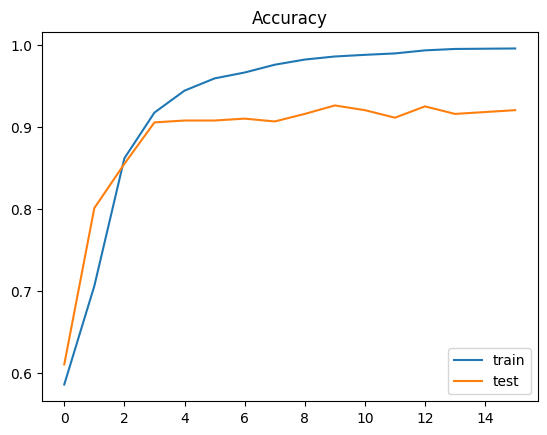

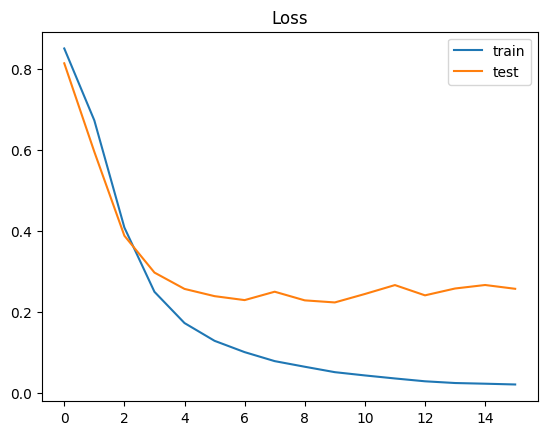

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.5691 - loss: 0.8505 - val_accuracy: 0.6211 - val_loss: 0.7914 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - accuracy: 0.7524 - loss: 0.5999 - val_accuracy: 0.8220 - val_loss: 0.4833 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.8828 - loss: 0.3406 - val_accuracy: 0.8714 - val_loss: 0.3369 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9342 - loss: 0.1964 - val_accuracy: 0.9036 - val_loss: 0.2679 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.9560 - loss: 0.1367 - val_accuracy: 0.9150 - val_loss: 0.2464 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.9673 - loss: 0.1007 - val_accuracy: 0.9208 - val_loss: 0.2375 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.9718 - los

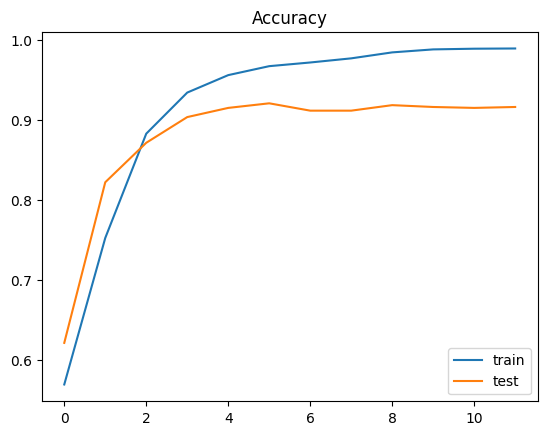

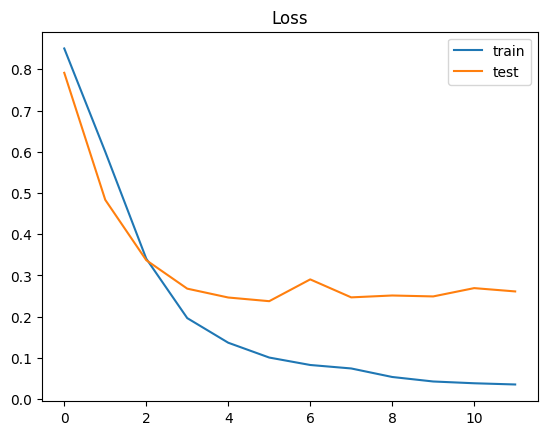

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.5892 - loss: 0.8205 - val_accuracy: 0.6831 - val_loss: 0.7293 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 131ms/step - accuracy: 0.7845 - loss: 0.5403 - val_accuracy: 0.8622 - val_loss: 0.4224 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.8980 - loss: 0.2836 - val_accuracy: 0.8955 - val_loss: 0.2917 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.9440 - loss: 0.1633 - val_accuracy: 0.9093 - val_loss: 0.2517 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.9624 - loss: 0.1119 - val_accuracy: 0.9173 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.9724 - loss: 0.0793 - val_accuracy: 0.9150 - val_loss: 0.2181 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - accuracy: 0.9

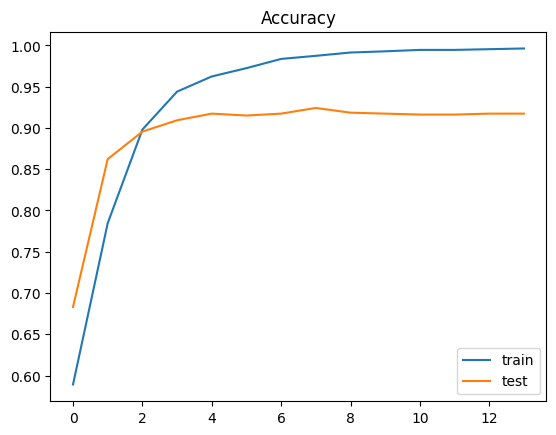

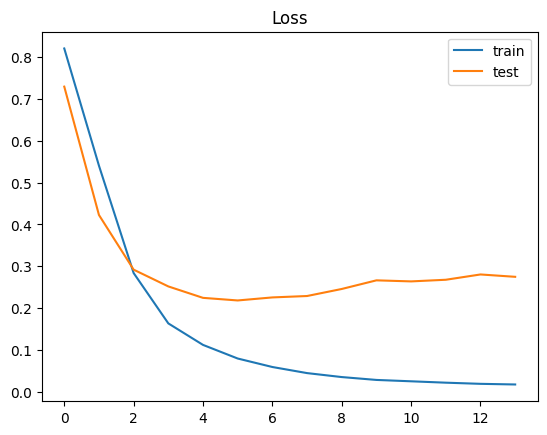

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 25s 218ms/step - accuracy: 0.5990 - loss: 0.8126 - val_accuracy: 0.7222 - val_loss: 0.6526 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.7837 - loss: 0.5464 - val_accuracy: 0.8416 - val_loss: 0.4285 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 243ms/step - accuracy: 0.8793 - loss: 0.3369 - val_accuracy: 0.8462 - val_loss: 0.4539 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.9132 - loss: 0.2475 - val_accuracy: 0.8898 - val_loss: 0.2850 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 233ms/step - accuracy: 0.9420 - loss: 0.1625 - val_accuracy: 0.8932 - val_loss: 0.2509 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 26s 235ms/step - accuracy: 0.9606 - loss: 0.1166 - val_accuracy: 0.9185 - val_loss: 0.2524 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 41s 239ms/step - accuracy: 0.9

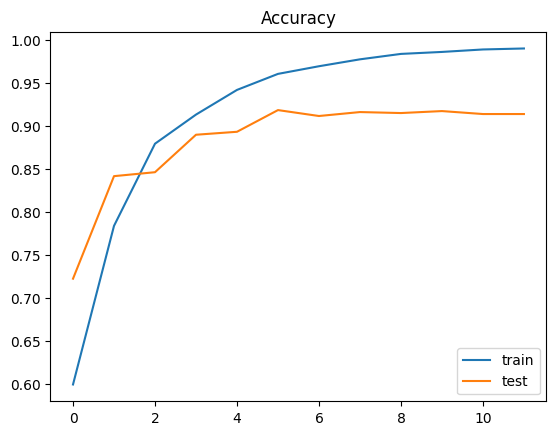

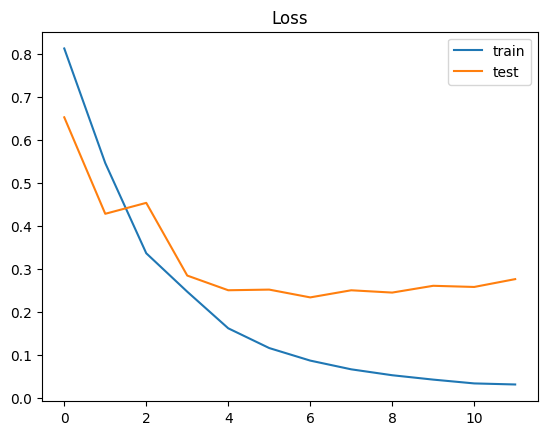

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 54s 477ms/step - accuracy: 0.6171 - loss: 0.7811 - val_accuracy: 0.7026 - val_loss: 0.6442 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 79s 457ms/step - accuracy: 0.8342 - loss: 0.4407 - val_accuracy: 0.8886 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 80s 439ms/step - accuracy: 0.9178 - loss: 0.2340 - val_accuracy: 0.8439 - val_loss: 0.5132 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 82s 436ms/step - accuracy: 0.9348 - loss: 0.1947 - val_accuracy: 0.9150 - val_loss: 0.2277 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 82s 436ms/step - accuracy: 0.9629 - loss: 0.1009 - val_accuracy: 0.9162 - val_loss: 0.2154 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 50s 459ms/step - accuracy: 0.9785 - loss: 0.0693 - val_accuracy: 0.9127 - val_loss: 0.2167 - learning_rate: 0.0010
Epoch 7/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 79s 435ms/step - accuracy: 0.9

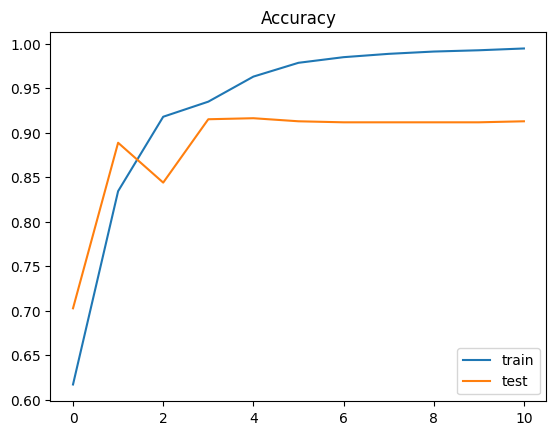

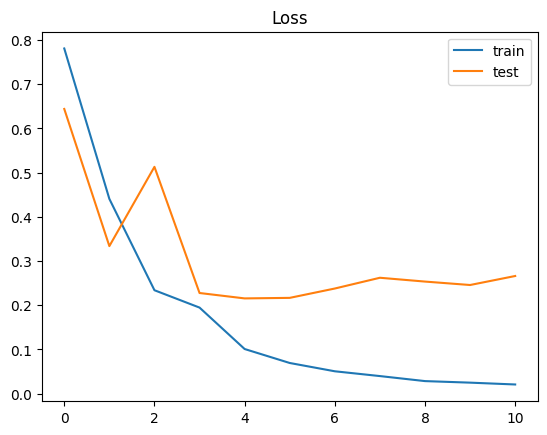

Epoch 1/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 101s 914ms/step - accuracy: 0.6487 - loss: 0.7528 - val_accuracy: 0.8014 - val_loss: 0.5749 - learning_rate: 0.0010
Epoch 2/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 95s 875ms/step - accuracy: 0.8607 - loss: 0.3698 - val_accuracy: 0.8921 - val_loss: 0.3043 - learning_rate: 0.0010
Epoch 3/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 101s 918ms/step - accuracy: 0.9319 - loss: 0.1879 - val_accuracy: 0.9024 - val_loss: 0.2533 - learning_rate: 0.0010
Epoch 4/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 137s 871ms/step - accuracy: 0.9595 - loss: 0.1154 - val_accuracy: 0.8772 - val_loss: 0.3604 - learning_rate: 0.0010
Epoch 5/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 95s 871ms/step - accuracy: 0.9684 - loss: 0.0938 - val_accuracy: 0.9013 - val_loss: 0.2692 - learning_rate: 0.0010
Epoch 6/30
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9833 - loss: 0.0558
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
109/109 ━━━━━━━━━━━━━━━━━━━━ 100s 910ms/step - accuracy: 0

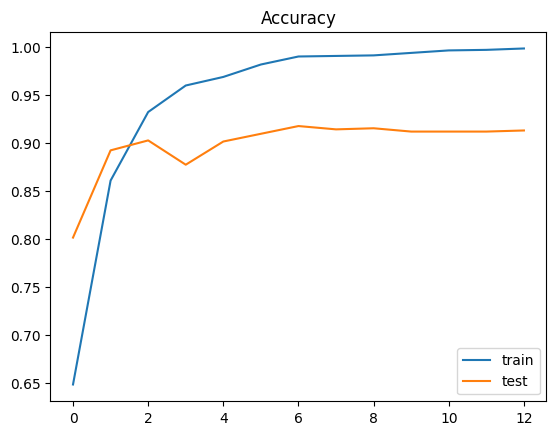

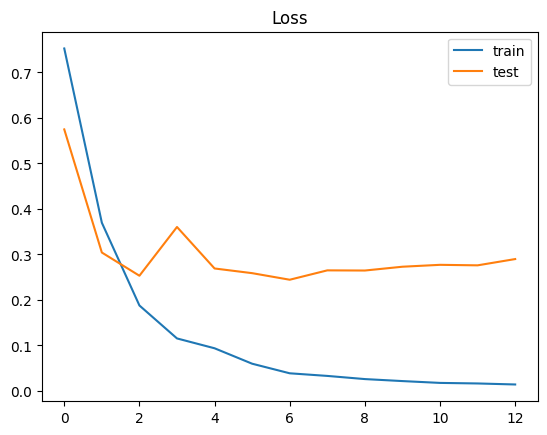

In [ ]:
accuracies = []
for kernel_size in [2,4,8,16,32,64,128]:
  rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1)
  es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=6)

  model = cnn1D_small(vocab_size = max_words, emb_len=50,seq_len=x_train_seq.shape[1], n=128, kernel_size = kernel_size)
  #model.summary()
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  history = model.fit(
    x_train_seq, y_train,
    validation_data=(x_test_seq, y_test),
    epochs = 30,
    verbose = 1,
    batch_size=32,
    callbacks = [rop, es]
  )
  acc = history.history['val_accuracy']
  print('kernel size=',kernel_size)
  print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
  accuracies.append(acc[-1])
  plot_results(history)

In [ ]:
print(accuracies)

[0.9207807183265686, 0.9207807183265686, 0.9161882996559143, 0.9173364043235779, 0.9138920903205872, 0.9127439856529236, 0.9127439856529236]


### Inspect the Learned Embedding Space

Now let's observe the similarity or dissimilarity of the embeddings of various words to see if they match our expectations. Words with related meanings or usage can develop similar embedding vectors during training.


In [ ]:
embedding_matrix = model.get_weights()[0]
print(embedding_matrix.shape)

(15000, 50)


In [ ]:
# Define the cosine similarity of two words.
def cosine_similarity(w1,w2,emb,word_index):
  e1,e2 = emb[word_index[w1]], emb[word_index[w2]]
  cs = np.dot(e1,e2)/np.linalg.norm(e1)/np.linalg.norm(e2)
  print('cosine similarity({},{})={:4.3f}'.format(w1,w2,cs))

# Extract embedding matrix from trained network
embedding_matrix = model.get_weights()[0]
print(embedding_matrix.shape)

# Show (dis)similarities
W1 = ['buck','dracula','holmes']
W2 = ['deer','wolf','spitz','blood','vampire','detective','watson']
for w1 in W1:
  for w2 in W2:
      cosine_similarity(w1,w2,embedding_matrix,word_index)

(15000, 50)
cosine similarity(buck,deer)=0.123
cosine similarity(buck,wolf)=0.444
cosine similarity(buck,spitz)=0.967
cosine similarity(buck,blood)=0.189
cosine similarity(buck,vampire)=0.034
cosine similarity(buck,detective)=-0.118
cosine similarity(buck,watson)=-0.212
cosine similarity(dracula,deer)=0.412
cosine similarity(dracula,wolf)=0.856
cosine similarity(dracula,spitz)=0.026
cosine similarity(dracula,blood)=0.928
cosine similarity(dracula,vampire)=0.917
cosine similarity(dracula,detective)=0.372
cosine similarity(dracula,watson)=-0.951
cosine similarity(holmes,deer)=-0.409
cosine similarity(holmes,wolf)=-0.930
cosine similarity(holmes,spitz)=-0.176
cosine similarity(holmes,blood)=-0.951
cosine similarity(holmes,vampire)=-0.910
cosine similarity(holmes,detective)=-0.322
cosine similarity(holmes,watson)=0.978


# Text Classification Using Pretrained Word Embeddings


We will see how we can also initialize our embedding matrix with pretrained values.

We can download a zip file containing word embeddings of lengths 50,100,200, and 300.

In [85]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

--2026-09-08 22:19:08--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-09-08 22:19:08--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-09-08 22:19:08--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

gl

Now we'll build a dictionary where embedding[w] contains the embedding of word w. We will use embeddings of length 50.

In [88]:
import numpy as np

def read_embeddings(n=1000):
    # Reads n embeddings from file
    # Returns a dictionary were embedding[w] is the embeding of string w
    embedding = {}
    count = 0
    with open('glove.6B.50d.txt', encoding="utf8") as f:
        for line in f:
            count+=1
            ls = line.split(" ")
            emb = np.array([np.float32(x) for x in ls[1:]])
            embedding[ls[0]]=emb
            if count>= n:
                break
    return embedding

vocabulary_size = 1000000000
embedding = read_embeddings(vocabulary_size)

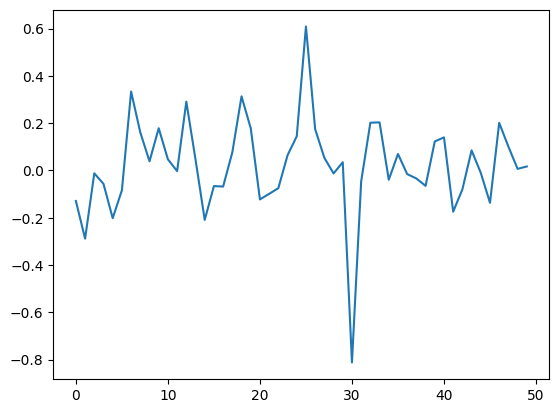

In [89]:
emb_mat = np.zeros((len(embedding),len(embedding['a'])))
for i, k in enumerate(embedding.keys()):
  emb_mat[i] = embedding[k]

plt.plot(np.mean(emb_mat,axis=0))

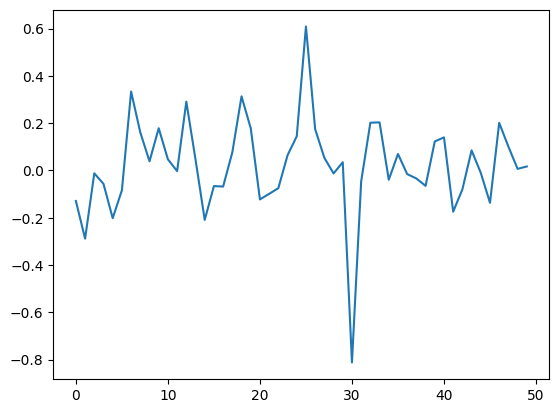

In [90]:
plt.plot(np.mean(emb_mat,axis=0))

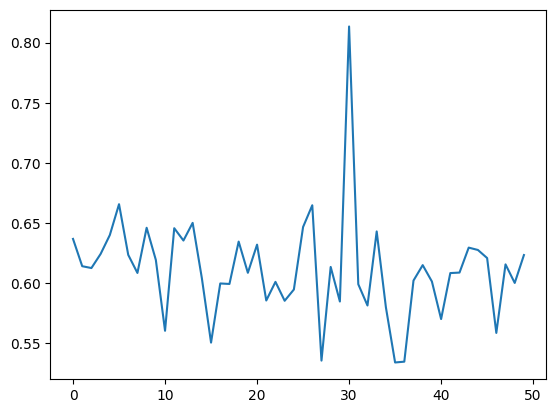

In [91]:
plt.plot(np.std(emb_mat,axis=0))

In [92]:
print(np.std(emb_mat))
print(np.mean(emb_mat))

0.6441042976810656
0.020940489511124018


In [93]:
num_tokens = len(tokenizer.word_index)+1
embedding_dim = len(embedding['a'])
hits = 0
misses = 0

# Prepare embedding matrix
embedding_matrix = np.zeros((num_tokens, embedding_dim)) + np.mean(emb_mat,axis=0,keepdims=True)
#yembedding_matrix = np.random.normal(loc=0.0, scale=0.1, size=(num_tokens, embedding_dim))
for word, i in tokenizer.word_index.items():

    embedding_vector = embedding.get(word)
    if embedding_vector is not None:
        # Words not found in embedding index will be all-zeros.
        # This includes the representation for "padding" and "OOV"
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1
print("Converted %d words (%d misses)" % (hits, misses))
print(embedding_matrix.shape)

Converted 12064 words (1929 misses)
(13994, 50)


In [94]:
embedding_layer = Embedding(
    num_tokens,
    embedding_dim,
    embeddings_initializer=Constant(embedding_matrix),
    trainable=False,
)

In [95]:
def cnn1D(embedding_matrix, seq_len=250, n_classes=3,dropout=0.5,n=128):
  ks = 6
  model = tf.keras.models.Sequential()
  model.add(Embedding(embedding_matrix.shape[0],embedding_matrix.shape[1],input_length=seq_len,name='embeddings',embeddings_initializer=Constant(embedding_matrix),
    trainable=False))
  for i in range(1,3):
    model.add(Conv1D(n*i, kernel_size = ks, padding='same',activation="relu"))
    model.add(Conv1D(n*i, kernel_size = ks, padding='same',activation="relu"))
    model.add(MaxPooling1D(5, padding='same'))
    model.add(Dropout(dropout))


  model.add(Flatten())
  #model.add(Dense(n,activation= 'relu'))
  #model.add(Dropout(dropout/2))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

In [96]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=6)

model = cnn1D(embedding_matrix=embedding_matrix, seq_len=seq_len, n=128)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])
history = model.fit(
    x_train_seq, y_train,
    validation_data=(x_test_seq, y_test),
    epochs = 100,
    verbose = 1,
    batch_size=32,
    callbacks = [rop, es]
)
acc = history.history['val_accuracy']
print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embeddings (Embedding)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 301ms/step - accuracy: 0.5633 - loss: 0.8740 - val_accuracy: 0.5855 - val_loss: 0.8780 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 37s 339ms/step - accuracy: 0.5837 - loss: 0.7887 - val_accuracy: 0.6154 - val_loss: 0.7475 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 304ms/step - accuracy: 0.6656 - loss: 0.6886 - val_accuracy: 0.6877 - val_loss: 0.6380 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 303ms/step - accuracy: 0.7799 - loss: 0.5112 - val_accuracy: 0.7405 - val_loss: 0.5549 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 35s 321ms/step - accuracy: 0.8273 - loss: 0.4074 - val_accuracy: 0.8071 - val_loss: 0.4646 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 33s 302ms/step - accuracy: 0.8601 - loss: 0.3360 - val_accuracy: 0.8106 - val_loss: 0.4566 - learning_rate: 0.0010
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 39s 357ms/step - accura

In [97]:
def cnn1D_small(embedding_matrix, seq_len=250, n_classes=3,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()
  model.add(Embedding(embedding_matrix.shape[0],embedding_matrix.shape[1],input_length=seq_len,name='embeddings',embeddings_initializer=Constant(embedding_matrix),trainable=True))
  model.add(Conv1D(n, kernel_size = 32, padding='same', activation="relu"))
  model.add(Dropout(dropout))
  model.add(GlobalAveragePooling1D())
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embeddings (Embedding)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_39 (Conv1D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_17     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - accuracy: 0.6176 - loss: 0.7731 - val_accuracy: 0.6854 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 2/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - accuracy: 0.7423 - loss: 0.5847 - val_accuracy: 0.8117 - val_loss: 0.5475 - learning_rate: 0.0010
Epoch 3/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - accuracy: 0.8391 - loss: 0.4112 - val_accuracy: 0.8599 - val_loss: 0.3917 - learning_rate: 0.0010
Epoch 4/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.8776 - loss: 0.3139 - val_accuracy: 0.8726 - val_loss: 0.3340 - learning_rate: 0.0010
Epoch 5/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.9216 - loss: 0.2192 - val_accuracy: 0.8944 - val_loss: 0.2951 - learning_rate: 0.0010
Epoch 6/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9397 - loss: 0.1768 - val_accuracy: 0.8875 - val_loss: 0.3583 - learning_rate: 0.0010
Epoch 7/100
109/109 ━━━━━━━━━━━━━━━━━━━━ 16s 142ms/step - accura

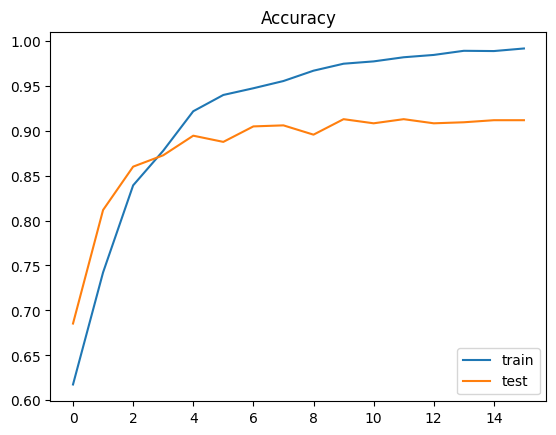

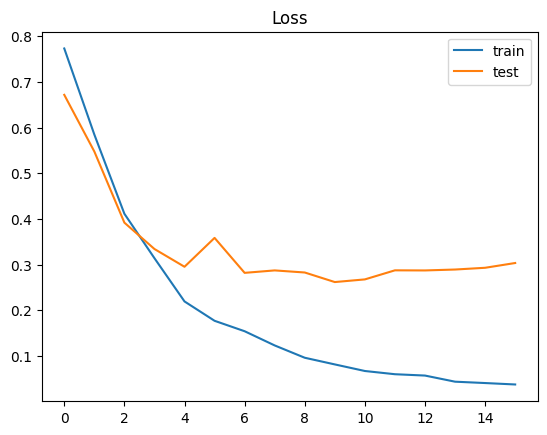

In [98]:
rop = ReduceLROnPlateau(monitor='val_loss',factor=0.5, patience=3, verbose=1)
es = EarlyStopping(monitor='val_accuracy', verbose=1, patience=6)

model = cnn1D_small(embedding_matrix=embedding_matrix, seq_len=seq_len, n=64)
#model = cnn1D_small(seq_len=seq_len, n=128)
model.summary()
model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(), metrics=['accuracy'])
history = model.fit(
    x_train_seq, y_train,
    validation_data=(x_test_seq, y_test),
    epochs = 100,
    verbose = 1,
    batch_size=32,
    callbacks = [rop, es]
)
acc = history.history['val_accuracy']
print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)

## Part 2: Four-Book Extension

This section uses four books and a second sequence-construction workflow. It preserves the manual tokenization, vocabulary inspection, Dense baseline, convolutional models, LSTM model, and GloVe-initialized models.

The manual vocabulary in this workflow is constructed before the train/test split, so this section is most useful as an architecture and representation comparison. The earlier Keras-tokenizer workflow demonstrates the stricter train-fitted vocabulary procedure.


We will download 4 books:


*   The Call of the Wild, by Jack London
*   Dracula, by Bram Stoker
*   The Adventures of Sherlock Holmes, by Arthur Conan Doyle
*   Twenty Thousand Leagues under the Sea, by Jules Verne

We will split the books into a collection of paragraphs and train a machine learning model to determine the book a paragraph was taken from.

In [99]:
import bs4 as bs
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from tensorflow.keras.optimizers import *

from keras.models import Model
from keras.regularizers import l2

from tensorflow.keras.preprocessing.text import Tokenizer

from keras.utils import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback, LearningRateScheduler

In [100]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

In [101]:
def get_paragraph_list(url,skip):
    paragraphs = []
    data = urllib.request.urlopen(url).read()
    soup = bs.BeautifulSoup(data,'lxml')
    for paragraph in soup.find_all('p'):
        par  = paragraph.get_text()
        if par:
            if len(par)>=30:
              paragraphs.append(par)
    return paragraphs[skip:]


url_list = ['http://www.gutenberg.org/files/215/215-h/215-h.htm', 'http://www.gutenberg.org/files/345/345-h/345-h.htm',
            'http://www.gutenberg.org/files/1661/1661-h/1661-h.htm','https://www.gutenberg.org/files/164/164-h/164-h.htm']

books = [215,345,1661,164]
url_list = [f'http://www.gutenberg.org/files/{i}/{i}-h/{i}-h.htm' for  i in books]

paragraphs = []
targets = []
first_par = []
skip = [1,4,0,0]
for u, url in enumerate(url_list):
    par = get_paragraph_list(url,skip[u])
    paragraphs = paragraphs + par
    targets = targets + [u for i in par]
    print('\nBook {} contains {} paragraphs'.format(u,len(par)))
    lengths = np.array([len(wl) for wl in par])
    print('Paragraph length stats:')
    print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
    print('First paragraph:')
    print(par[0])

targets = np.array(targets)


Book 0 contains 327 paragraphs
Paragraph length stats:
min = 43 max = 1558 mean = 534.504587
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1745 paragraphs
Paragraph length stats:
min = 30 max = 4713 mean = 473.446418
First paragraph:
3 May. Bistritz.—Left Munich at 8:35 P. M., on 1st May, arriving at
Vienna early next morning; should have arrived at 6:46, but train was an
hour late. Buda-Pesth seems a wonderful place, from the glimpse which I
got of

### Integer Sequences and Fixed Length

Now let's extract integer sequences to describe the data.

Since all sequences must have the same length, we choose a length and pad shorter sequences with zeros while truncating longer sequences.

The vocabulary is sorted by frequency and each word is assigned an integer index. The sequence array stores those integer indices.


In [102]:
len(paragraphs)

6296

In [103]:
p = np.random.randint(0,len(paragraphs))
print(paragraphs[p])


“In the eighty-ninth genus of fishes, classed by Lacepede, belonging to the
second lower class of bony, characterised by opercules and bronchial membranes,
I remarked the scorpaena, the head of which is furnished with spikes, and which
has but one dorsal fin; these creatures are covered, or not, with little
shells, according to the sub-class to which they belong. The second sub-class
gives us specimens of didactyles fourteen or fifteen inches in length, with
yellow rays, and heads of a most fantastic appearance. As to the first
sub-class, it gives several specimens of that singular looking fish
appropriately called a ‘seafrog,’ with large head, sometimes pierced with
holes, sometimes swollen with protuberances, bristling with spikes, and covered
with tubercles; it has irregular and hideous horns; its body and tail are
covered with callosities; its sting makes a dangerous wound; it is both
repugnant and horrible to look at.”



In [104]:
from nltk.tokenize import wordpunct_tokenize
p_tok = [wordpunct_tokenize(p) for p in paragraphs]

In [105]:
print(p_tok[0])

['Buck', 'did', 'not', 'read', 'the', 'newspapers', ',', 'or', 'he', 'would', 'have', 'known', 'that', 'trouble', 'was', 'brewing', ',', 'not', 'alone', 'for', 'himself', ',', 'but', 'for', 'every', 'tide', '-', 'water', 'dog', ',', 'strong', 'of', 'muscle', 'and', 'with', 'warm', ',', 'long', 'hair', ',', 'from', 'Puget', 'Sound', 'to', 'San', 'Diego', '.', 'Because', 'men', ',', 'groping', 'in', 'the', 'Arctic', 'darkness', ',', 'had', 'found', 'a', 'yellow', 'metal', ',', 'and', 'because', 'steamship', 'and', 'transportation', 'companies', 'were', 'booming', 'the', 'find', ',', 'thousands', 'of', 'men', 'were', 'rushing', 'into', 'the', 'Northland', '.', 'These', 'men', 'wanted', 'dogs', ',', 'and', 'the', 'dogs', 'they', 'wanted', 'were', 'heavy', 'dogs', ',', 'with', 'strong', 'muscles', 'by', 'which', 'to', 'toil', ',', 'and', 'furry', 'coats', 'to', 'protect', 'them', 'from', 'the', 'frost', '.']


In [106]:
count = {}

for p in p_tok:
  for w in p:
    w = w.lower()
    count[w] = count.get(w,0)+1

vocabulary = list(count.keys())
frequencies = list(count.values())
vocabulary = ['UNKNOWN'] + [vocabulary[i] for i in np.argsort(frequencies)][::-1]

max_len = 128

index = {}
for i,w in enumerate(vocabulary):
    index[w] = i

seq_arr = np.zeros((len(paragraphs),max_len),dtype=int)
for i,p in enumerate(p_tok):
  ind_seq = []
  for w in p[:max_len]:
    ind_seq.append(index.get(w.lower(),0))
  seq_arr[i,-len(ind_seq):] = ind_seq

print(len(vocabulary))
max_words = len(vocabulary)

17547


In [107]:
seq_arr[0]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,   155,    85,    20,   363,
           2,  2976,     1,    64,    12,    58,    32,   529,    10,
         520,    13, 17538,     1,    20,   324,    21,   179,     1,
          28,    21,   205,  1155,    29,   160,   365,     1,   336,
           5,  4763,     4,    17,  1418,     1,   125,   493,     1,
          40, 10609,   434,     6,  3810, 10619,     3,   350,   166,
           1,  4762,     9,     2,  3807,   540,     1,    26,   158,
           8,   946,  1412,     1,     4,   350, 10603,     4, 10608,
        6907,    44,  5427,     2,   225,     1,  1583,     5,   166,
          44,  1528,    73,     2,  4759,     3,   113,   166,   600,
         334,     1,     4,     2,   334,    50,   600,    44,   398,
         334,     1,    17,   336,  2059,    41,    33,     6,  2133,
           1,     4,  5423,  5426,     6,  2220,    66,    40,     2,
        2484,     3]

In [108]:
print(len(vocabulary))

17547


In [109]:
print(vocabulary[:20])

['UNKNOWN', ',', 'the', '.', 'and', 'of', 'to', 'i', 'a', 'in', 'that', 'it', 'he', 'was', '“', 'his', 'you', 'with', 'is', 'as']


In [110]:
print(vocabulary[-20:])

['cataract', 'exploration', 'fascinate', 'accomplices', 'nuisance', 'attracting', 'retaliations', 'omitted', 'revise', 'monthly', 'embraced', 'brewing', 'accelerated', 'labouring', 'slackening', 'filtering', 'balustrade', 'undefinable', 'enormously', 'foundered']


In [111]:
print(f'{index["vampire"] = }')
print(f'{index["dracula"] = }')
print(f'{index["buck"] = }')
print(f'{index["dog"] = }')
print(f'{index["holmes"] = }')
print(f'{index["watson"] = }')
print(f'{index["nemo"] = }')
print(f'{index["submarine"] = }')

index["vampire"] = 1416
index["dracula"] = 1246
index["buck"] = 155
index["dog"] = 365
index["holmes"] = 131
index["watson"] = 552
index["nemo"] = 147
index["submarine"] = 571


### Train/Test Split


In [112]:
x_train, x_test, y_train, y_test = train_test_split(seq_arr, targets, test_size=0.2, random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(5036, 128)
(5036,)
(1260, 128)
(1260,)


Let's see a random training example and its corresponding sequence representation.

In [113]:
r = np.random.randint(len(x_train))
print(x_train[r])

[   0    0    0   31   10  107    2 1481  199   13 2115   17 2250 6110
    3   95  106  397  482    6   34  572   40    2  304    3  106  397
   95 1606   68   40    2  211  140    3   28    2 1133   44  711 3749
    5  233    3    2  110   10  482 1067    6   34  381   21    2 6245
   22   20    8 6669   21    2  112    3   46    7  111  108   31  393
    1    7   13  193 4238    3   59    8  105   70    7   92   20  133
    6 1941   11    3    2  395  107   23  956   13 3103    3 8885 2545
    2  635    9   23  188    4  115   30   94    8 4784   79    3   23
  616  477    2  215 3917    3   60    5    2  651   26 5398    9    2
  569    3]


In [114]:
for i in x_train[r]:
  if i>0:
    print(vocabulary[i],end = ' ')

on that day the ordinary work was accomplished with unusual vigour . only two yards remained to be raised from the surface . two yards only separated us from the open sea . but the reservoirs were nearly emptied of air . the little that remained ought to be kept for the workers ; not a particle for the nautilus . when i went back on board , i was half suffocated . what a night ! i know not how to describe it . the next day my breathing was oppressed . dizziness accompanied the pain in my head and made me like a drunken man . my companions showed the same symptoms . some of the crew had rattling in the throat . 

Words with indices greater than max_words appear in word_index, but are not included in the training or test sequences. These are usually rare words.

### Embedding Layer

The embedding layer receives integer word indices and maps each word to a trainable dense vector. These vectors are learned together with the text classifier.


### Dense Classifier with Learned Embeddings


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3584 - loss: 1.2445 - val_accuracy: 0.3770 - val_loss: 1.2139
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4452 - loss: 1.1551 - val_accuracy: 0.5508 - val_loss: 1.0991
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6070 - loss: 0.9520 - val_accuracy: 0.6587 - val_loss: 0.8566
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7369 - loss: 0.6957 - val_accuracy: 0.7437 - val_loss: 0.6431
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8229 - loss: 0.4962 - val_accuracy: 0.8333 - val_loss: 0.5028
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8850 - loss: 0.3597 - val_accuracy: 0.8556 - val_loss: 0.4075
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9140 - loss: 0.2679 - val_accuracy: 0.8714 - val_loss: 0.3490
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9307 - loss: 0.2162 - val_accuracy: 0.

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 128, 20)        │       350,940 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │       163,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,545,314 (5.89 MB)

 Trainable params: 515,104 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,030,210 (3.93 MB)

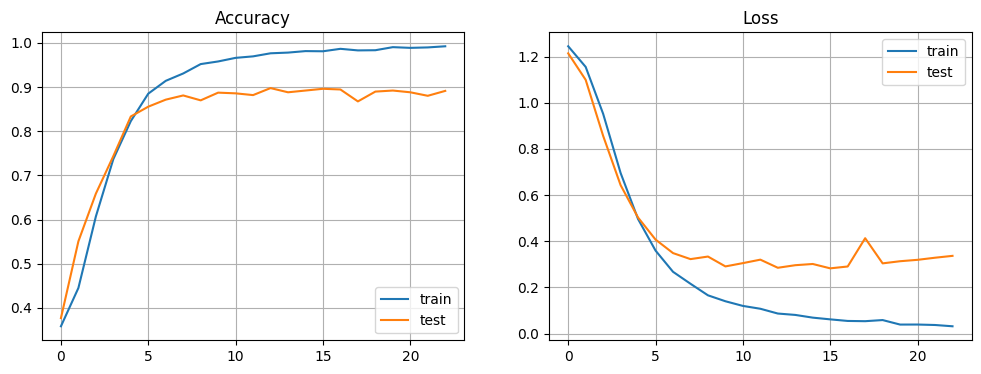

The highest training accuracy was 0.9923 obtained in epoch 23
The final training accuracy was 0.9923
The highest validation accuracy was 0.8976 obtained in epoch 13
The final validation accuracy was 0.8913
The lowest training loss was 0.0321 obtained in epoch 23
The final training loss was 0.0321
The lowest validation loss was 0.2829 obtained in epoch 16
The final validation loss was 0.3370
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion matrix:
[[ 67   6   7   2]
 [  0 297  39   9]
 [  0  15 402   7]
 [  0  11  33 365]]
Accuracy: 0.897619


In [115]:
def simple_model(vocab_size,emb_len=50, n_classes=4):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Flatten())
  model.add(Dropout(0.5))
  model.add(Dense(64, activation = 'relu'))
  model.add(Dropout(0.5))
  model.add(Dense(n_classes, activation = 'softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model = simple_model(vocab_size = len(vocabulary), emb_len=20, n_classes=4)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')

### Additional Dense Training Configuration

The same Dense embedding classifier is also evaluated with a different training configuration. This experiment uses a batch size of 64 and an early-stopping patience of 8, providing a direct comparison with the other Dense training configuration.


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3713 - loss: 1.2264 - val_accuracy: 0.4579 - val_loss: 1.1861
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5328 - loss: 1.0654 - val_accuracy: 0.6238 - val_loss: 0.9277
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7309 - loss: 0.7409 - val_accuracy: 0.7675 - val_loss: 0.6048
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8463 - loss: 0.4587 - val_accuracy: 0.8484 - val_loss: 0.4402
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9053 - loss: 0.2991 - val_accuracy: 0.8770 - val_loss: 0.3360
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9269 - loss: 0.2296 - val_accuracy: 0.8675 - val_loss: 0.3330
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9464 - loss: 0.1720 - val_accuracy: 0.8659 - val_loss: 0.3516
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9567 - loss: 0.1360 - val_accuracy: 0.

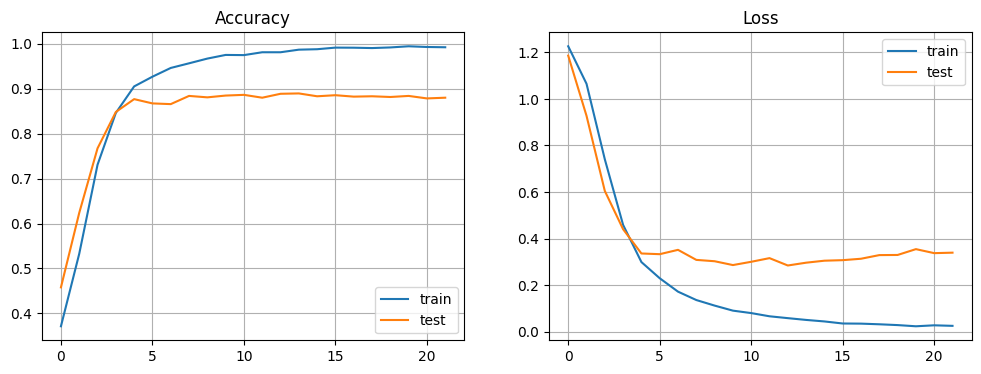

The highest training accuracy was 0.9946 obtained in epoch 20
The final training accuracy was 0.9925
The highest validation accuracy was 0.8897 obtained in epoch 14
The final validation accuracy was 0.8802
The lowest training loss was 0.0232 obtained in epoch 20
The final training loss was 0.0250
The lowest validation loss was 0.2844 obtained in epoch 13
The final validation loss was 0.3395
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion matrix:
[[ 62   5  10   5]
 [  1 294  37  13]
 [  0  18 386  20]
 [  0   9  21 379]]
Accuracy:
0.8896825396825396


In [116]:
def simple_model(vocab_size,emb_len=50, n_classes=4):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Flatten())
  model.add(Dropout(0.5))
  model.add(Dense(64, activation = 'relu'))
  model.add(Dropout(0.5))
  model.add(Dense(n_classes, activation = 'softmax'))
  return model


earlystopping = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model = simple_model(vocab_size = len(vocabulary), emb_len=20, n_classes=4)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 64,
    callbacks=[earlystopping]
)
acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print('Accuracy:')
print(accuracy_score(y_test, pred_class))

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 358ms/step - accuracy: 0.3360 - loss: 1.2551 - val_accuracy: 0.3294 - val_loss: 1.2866 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 351ms/step - accuracy: 0.3423 - loss: 1.2291 - val_accuracy: 0.3770 - val_loss: 1.2590 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 318ms/step - accuracy: 0.3866 - loss: 1.1718 - val_accuracy: 0.4754 - val_loss: 1.1195 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 346ms/step - accuracy: 0.5614 - loss: 0.8834 - val_accuracy: 0.6095 - val_loss: 0.8202 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 348ms/step - accuracy: 0.6777 - loss: 0.6687 - val_accuracy: 0.7286 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 332ms/step - accuracy: 0.8255 - loss: 0.4570 - val_accuracy: 0.7468 - val_loss: 0.6700 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 347ms/step - accuracy: 0.8642 - l

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 128, 50)        │       877,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 128, 64)        │        16,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 128, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_42 (Conv1D)              │ (None, 32, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 32, 128)        │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 8, 256)         │       164,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 8, 256)         │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 2, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,686,656 (17.88 MB)

 Trainable params: 1,562,218 (5.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,124,438 (11.92 MB)

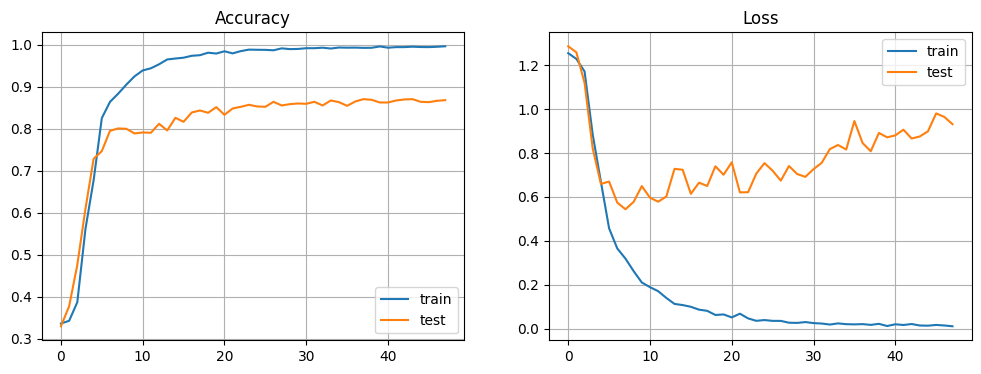

The highest training accuracy was 0.9966 obtained in epoch 48
The final training accuracy was 0.9966
The highest validation accuracy was 0.8706 obtained in epoch 38
The final validation accuracy was 0.8683
The lowest training loss was 0.0105 obtained in epoch 48
The final training loss was 0.0105
The lowest validation loss was 0.5438 obtained in epoch 8
The final validation loss was 0.9315
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step
Confusion matrix:
[[ 68   7   5   2]
 [ 18 282  38   7]
 [ 11  16 380  17]
 [  1  10  31 367]]
Accuracy: 0.870635


In [117]:
def cnn1D(vocab_size,emb_len=50, n_classes=3, dropout=0.5):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Dropout(dropout))
  for n_filters in [64,128,256]:
    model.add(Conv1D(n_filters, kernel_size = 5, activation="relu",padding='same'))
    model.add(Conv1D(n_filters, kernel_size = 5, activation="relu",padding='same'))
    model.add(MaxPooling1D(4))
    model.add(Dropout(dropout))
  model.add(Flatten())
  model.add(Dense(64,activation= 'relu'))
  model.add(Dropout(dropout))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

model = cnn1D(vocab_size = len(vocabulary), emb_len=50, n_classes=4)

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping,reduce_lr]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 253ms/step - accuracy: 0.4241 - loss: 1.1887 - val_accuracy: 0.5365 - val_loss: 1.2210 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 296ms/step - accuracy: 0.6297 - loss: 0.9737 - val_accuracy: 0.7079 - val_loss: 0.9830 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 301ms/step - accuracy: 0.8064 - loss: 0.5659 - val_accuracy: 0.8365 - val_loss: 0.6595 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 259ms/step - accuracy: 0.9047 - loss: 0.3044 - val_accuracy: 0.8817 - val_loss: 0.4783 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 298ms/step - accuracy: 0.9394 - loss: 0.1926 - val_accuracy: 0.8889 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 264ms/step - accuracy: 0.9613 - loss: 0.1269 - val_accuracy: 0.8984 - val_loss: 0.3618 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 300ms/step - accuracy: 0.9740 - l

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 128, 50)        │       877,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 109, 128)       │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 109, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,017,984 (11.51 MB)

 Trainable params: 1,005,994 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,011,990 (7.68 MB)

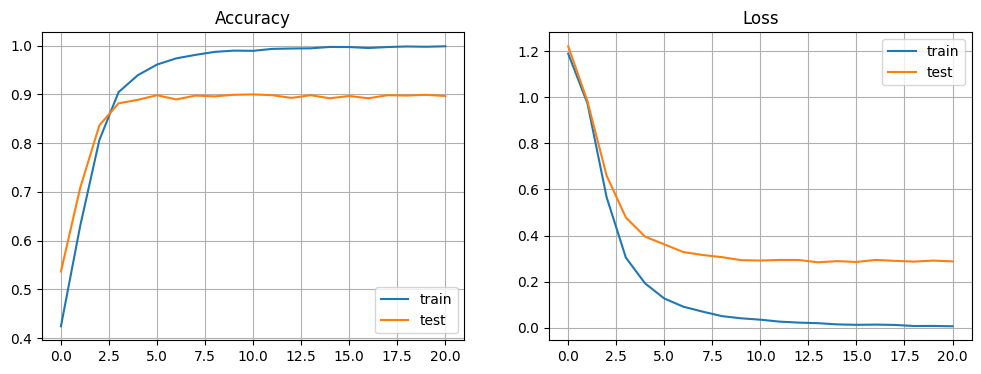

The highest training accuracy was 0.9988 obtained in epoch 21
The final training accuracy was 0.9988
The highest validation accuracy was 0.9000 obtained in epoch 11
The final validation accuracy was 0.8968
The lowest training loss was 0.0065 obtained in epoch 21
The final training loss was 0.0065
The lowest validation loss was 0.2840 obtained in epoch 14
The final validation loss was 0.2879
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Confusion matrix:
[[ 72   4   6   0]
 [  0 303  29  13]
 [  0  14 394  16]
 [  1  19  24 365]]
Accuracy: 0.900000


In [118]:
def cnn1D_small(vocab_size,emb_len=100, n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Dropout(dropout))
  model.add(Conv1D(n, kernel_size =20, activation="relu"))
  model.add(Dropout(dropout))
  model.add(GlobalMaxPooling1D())
  model.add(Dense(n_classes,activation= 'softmax'))
  return model


earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)
model = cnn1D_small(vocab_size = max_words, emb_len=50, n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping,reduce_lr]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - accuracy: 0.4015 - loss: 1.2621 - val_accuracy: 0.4484 - val_loss: 1.2221 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 20s 380ms/step - accuracy: 0.5453 - loss: 1.0899 - val_accuracy: 0.6198 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 377ms/step - accuracy: 0.6928 - loss: 0.7847 - val_accuracy: 0.7429 - val_loss: 0.6452 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 375ms/step - accuracy: 0.8131 - loss: 0.5202 - val_accuracy: 0.8437 - val_loss: 0.4455 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - accuracy: 0.8681 - loss: 0.3825 - val_accuracy: 0.8571 - val_loss: 0.3877 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 365ms/step - accuracy: 0.9073 - loss: 0.2695 - val_accuracy: 0.8690 - val_loss: 0.3609 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 387ms/step - accuracy: 0.9277 - l

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 128, 50)        │       877,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 128, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,814,464 (10.74 MB)

 Trainable params: 938,154 (3.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,876,310 (7.16 MB)

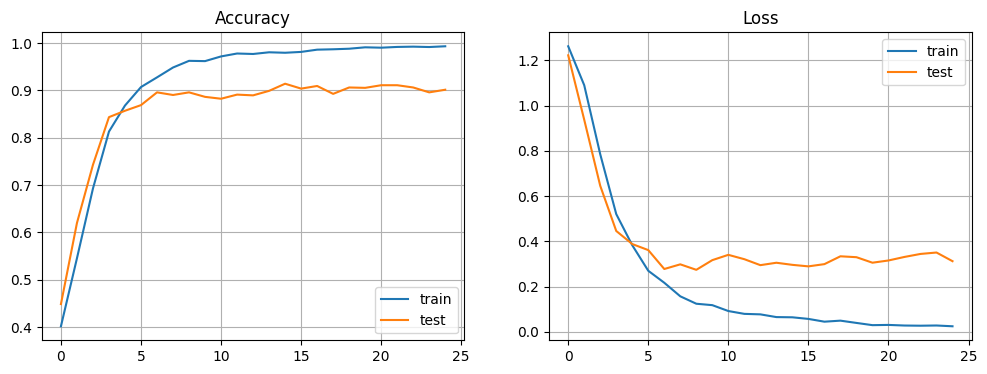

The highest training accuracy was 0.9934 obtained in epoch 25
The final training accuracy was 0.9934
The highest validation accuracy was 0.9143 obtained in epoch 15
The final validation accuracy was 0.9016
The lowest training loss was 0.0242 obtained in epoch 25
The final training loss was 0.0242
The lowest validation loss was 0.2738 obtained in epoch 9
The final validation loss was 0.3120
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step
Confusion matrix:
[[ 69   5   7   1]
 [  1 306  33   5]
 [  1  11 403   9]
 [  0  17  18 374]]
Accuracy: 0.914286


In [119]:
def recurrent_net(vocab_size,emb_len=100, seq_len=128, n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model


earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model = recurrent_net(vocab_size = max_words, emb_len=50, n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping,reduce_lr]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')


### Pretrained GloVe Initialization

The next experiments initialize the embedding layer with pretrained GloVe vectors and compare convolutional and recurrent classifiers.


In [120]:
def recurrent_net(vocab_size,embedding_matrix, emb_len=100, seq_len=128, n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=vocab_size,  # Vocabulary size
    output_dim=emb_len,  # Embedding dimension
    weights=[embedding_matrix]  # Initialize with pre-trained weights
  )
  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

#### Read Pretrained Embeddings


In [121]:
import numpy as np

def read_embeddings(n=1000):
    # Reads n embeddings from file
    # Returns a dictionary where embedding[w] is the embeding of string w
    embedding = {}
    count = 0
    with open('glove.6B.100d.txt', encoding="utf8") as f:
        for line in f:
            count+=1
            ls = line.split(" ")
            emb = np.array([np.float32(x) for x in ls[1:]])
            embedding[ls[0]]=emb
            if count>= n:
                break
    return embedding

vocabulary_size = 2000000
embedding = read_embeddings(vocabulary_size)

In [122]:
print(len(embedding))

400000


#### Build the Embedding Matrix

The embedding matrix has shape:

```text
vocabulary size × embedding length
```

Each row is filled with the GloVe vector for the corresponding vocabulary word when that word is available.


In [123]:
emb_mat = np.zeros((max_words, 100), dtype=np.float32)
words_in_ed = 0
for i, w in enumerate(vocabulary):
  if w in embedding:
    emb_mat[i] = embedding[w]
    words_in_ed += 1

print(words_in_ed,'words found in GloVe')

16424 words found in GloVe


#### Train Models with Pretrained Embeddings


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 28s 649ms/step - accuracy: 0.4365 - loss: 1.9557 - val_accuracy: 0.5984 - val_loss: 1.0243 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 555ms/step - accuracy: 0.6122 - loss: 0.9158 - val_accuracy: 0.6429 - val_loss: 0.9153 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 40s 522ms/step - accuracy: 0.6747 - loss: 0.7733 - val_accuracy: 0.7159 - val_loss: 0.8193 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 568ms/step - accuracy: 0.7327 - loss: 0.6572 - val_accuracy: 0.7675 - val_loss: 0.7238 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 41s 567ms/step - accuracy: 0.7635 - loss: 0.5886 - val_accuracy: 0.7627 - val_loss: 0.6672 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 520ms/step - accuracy: 0.7927 - loss: 0.5107 - val_accuracy: 0.7857 - val_loss: 0.6120 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 571ms/step - accuracy: 0.8094 - l

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 128, 100)       │     1,754,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 109, 128)       │       256,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 109, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,034,034 (23.02 MB)

 Trainable params: 2,011,344 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,022,690 (15.35 MB)

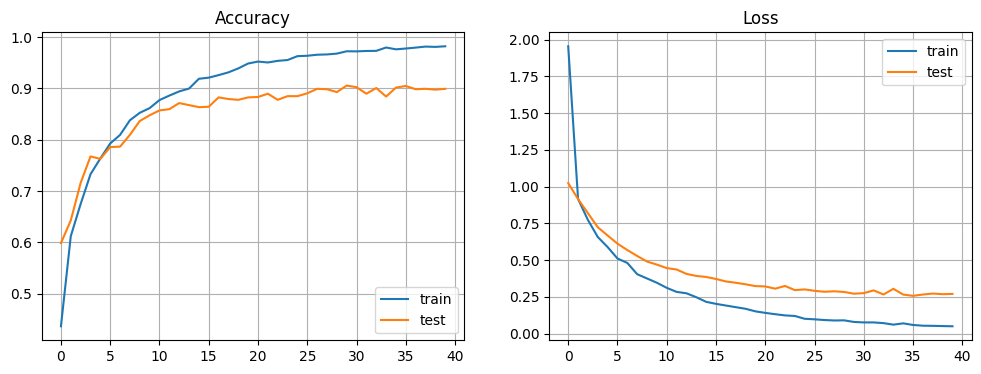

The highest training accuracy was 0.9821 obtained in epoch 40
The final training accuracy was 0.9821
The highest validation accuracy was 0.9056 obtained in epoch 30
The final validation accuracy was 0.8992
The lowest training loss was 0.0493 obtained in epoch 40
The final training loss was 0.0493
The lowest validation loss was 0.2567 obtained in epoch 36
The final validation loss was 0.2696
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Confusion matrix:
[[ 69   6   5   2]
 [  0 304  27  14]
 [  0  20 392  12]
 [  0  16  17 376]]
Accuracy: 0.905556


In [124]:
def cnn1D_small(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()
  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],  # Vocabulary size
    output_dim=embedding_matrix.shape[1],  # Embedding dimension
    weights=[embedding_matrix]  # Initialize with pre-trained weights
  )
  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(Conv1D(n, kernel_size =20, activation="relu"))
  model.add(Dropout(dropout))
  model.add(GlobalMaxPooling1D())
  model.add(Dense(n_classes,activation= 'softmax'))
  return model


earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model = cnn1D_small(emb_mat, n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping,reduce_lr]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 21s 461ms/step - accuracy: 0.4365 - loss: 1.1966 - val_accuracy: 0.4944 - val_loss: 1.1361 - learning_rate: 0.0010
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 19s 424ms/step - accuracy: 0.5586 - loss: 1.0269 - val_accuracy: 0.5992 - val_loss: 0.9344 - learning_rate: 0.0010
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 410ms/step - accuracy: 0.6503 - loss: 0.8780 - val_accuracy: 0.6937 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 421ms/step - accuracy: 0.7139 - loss: 0.7295 - val_accuracy: 0.7452 - val_loss: 0.6387 - learning_rate: 0.0010
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 421ms/step - accuracy: 0.7395 - loss: 0.6491 - val_accuracy: 0.7873 - val_loss: 0.5403 - learning_rate: 0.0010
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 422ms/step - accuracy: 0.7788 - loss: 0.5610 - val_accuracy: 0.7913 - val_loss: 0.5346 - learning_rate: 0.0010
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.8161 - l

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 128, 100)       │     1,754,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,506,514 (21.01 MB)

 Trainable params: 1,835,504 (7.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,671,010 (14.00 MB)

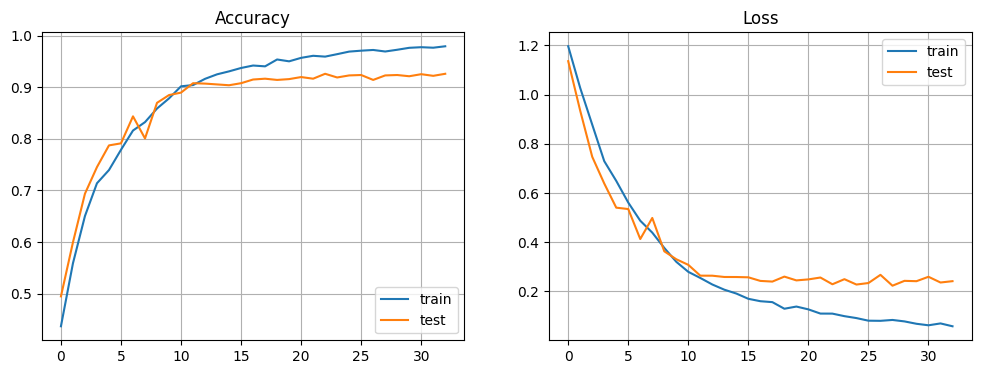

The highest training accuracy was 0.9795 obtained in epoch 33
The final training accuracy was 0.9795
The highest validation accuracy was 0.9262 obtained in epoch 23
The final validation accuracy was 0.9262
The lowest training loss was 0.0578 obtained in epoch 33
The final training loss was 0.0578
The lowest validation loss was 0.2229 obtained in epoch 28
The final validation loss was 0.2413
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step
Confusion matrix:
[[ 73   2   6   1]
 [  2 306  26  11]
 [  0   9 402  13]
 [  1   8  14 386]]
Accuracy: 0.926190


In [125]:
def recurrent_net(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],  # Vocabulary size
    output_dim=embedding_matrix.shape[1],  # Embedding dimension
    weights=[embedding_matrix]  # Initialize with pre-trained weights
  )

  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model


earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=5, verbose=1, min_lr=0.00005)

model = recurrent_net(emb_mat, n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs = 100,
    verbose = 1,
    batch_size = 128,
    callbacks=[earlystopping,reduce_lr]
)

model.summary()

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print(f'Accuracy:{accuracy_score(y_test, pred_class):9.6f}')

### Additional Compact Conv1D Classifier

This compact convolutional model uses a smaller embedding dimension, one Conv1D layer, strong dropout, global max pooling, and learning-rate reduction.


Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.3799 - loss: 1.2199 - val_accuracy: 0.3484 - val_loss: 1.3171 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4122 - loss: 1.1609 - val_accuracy: 0.5135 - val_loss: 1.2841 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.5485 - loss: 1.0167 - val_accuracy: 0.6643 - val_loss: 1.1553 - learning_rate: 0.0010
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7347 - loss: 0.7011 - val_accuracy: 0.7984 - val_loss: 0.9175 - learning_rate: 0.0010
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8263 - loss: 0.4744 - val_accuracy: 0.8540 - val_loss: 0.7567 - learning_rate: 0.0010
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8648 - loss: 0.3684 - val_accuracy: 0.8706 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.8894 - loss: 0.3133 - 

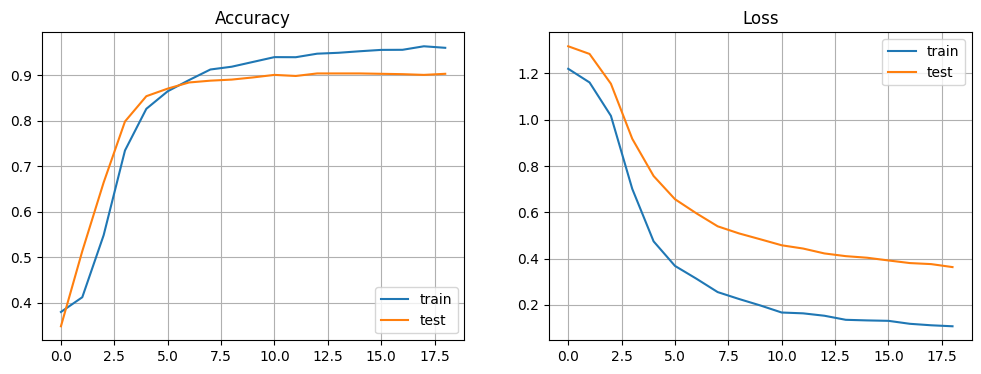

The highest training accuracy was 0.9637 obtained in epoch 18
The final training accuracy was 0.9603
The highest validation accuracy was 0.9040 obtained in epoch 13
The final validation accuracy was 0.9032
The lowest training loss was 0.1075 obtained in epoch 19
The final training loss was 0.1075
The lowest validation loss was 0.3632 obtained in epoch 19
The final validation loss was 0.3632
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Confusion matrix:
[[ 70   6   3   3]
 [  0 300  39   6]
 [  0  15 398  11]
 [  0  14  24 371]]
Accuracy:
0.903968253968254


In [126]:
def cnn1D_solution(vocab_size, emb_len=10, n_classes=4, dropout=0.7, n=128):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Embedding(vocab_size, emb_len))
    model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Conv1D(n, kernel_size=10, activation='relu'))
    model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.GlobalMaxPooling1D())
    model.add(tf.keras.layers.Dense(n_classes, activation='softmax'))
    return model


earlystopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.75,
    patience=1,
    verbose=1,
    min_lr=0.00005
)

model = cnn1D_solution(vocab_size=len(vocabulary), emb_len=10, n_classes=4)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    verbose=1,
    batch_size=64,
    callbacks=[earlystopping, reduce_lr]
)

acc = history.history['val_accuracy']
#print('max accuracy = {:.4f} in epoch {}, final accuracy = {:.4f}'.format(np.amax(acc),np.argmax(acc)+1,acc[-1]))
plot_results(history)
print_best_metrics(history.history)
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Confusion matrix:')
print(confusion_matrix(y_test, pred_class))
print('Accuracy:')
print(accuracy_score(y_test, pred_class))

## What the Embedding Layer Learns

The embedding layer starts with one vector for each vocabulary word. When embeddings are learned from scratch, backpropagation changes those vectors so that words useful in similar classification contexts can move toward related regions of the embedding space.

With pretrained GloVe initialization, the model starts from vectors learned from a much larger external corpus. The embedding layer can then be kept fixed or made trainable depending on the experiment.

The classifier therefore learns at two levels:

1. **word representation** through embedding vectors,
2. **document classification patterns** through Dense, Conv1D, or LSTM layers.


## Key Takeaways

- Tokenization converts text into word-level units.
- A vocabulary assigns integer indices to words.
- Integer sequences preserve word order.
- Padding produces fixed-length arrays that can be processed in batches.
- Learned embeddings replace sparse word indicators with compact trainable vectors.
- Conv1D learns local patterns across neighboring words.
- LSTM models sequential dependencies across the paragraph.
- Pretrained GloVe vectors provide an alternative initialization based on semantic information learned from a large external corpus.
